# Five-model DINO comparison dashboard

A single comparison flow for **Baseline**, **GT-guided AUX V1**, **BQR-DN V2**, **BQR-DN V3**, and **BQR-DN V3.1**. Every model is evaluated on the complete VOC2007 validation set.

> Standard VOC2007 reports AP@0.5. COCO-style AP/AP50/AP75, object-size AP/AR, and per-class AP are calculated from the same VOC predictions for research comparison.

In [1]:
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from gt_guided_dino.api import compute_coco_metrics, evaluate_checkpoint, evaluate_checkpoint_series
from gt_guided_dino.config import ExperimentConfig
from gt_guided_dino.data import build_datasets

d:\BQR_DETR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
EVALUATION_PRECISION = 'fp16'  # Use 'fp32' without CUDA.
FORCE_FULL_EVALUATION = False
RUN_CONVERGENCE_EVALUATION = False
CONVERGENCE_VAL_IMAGES = 250

MODEL_SPECS = {
    'Baseline': {'method': 'baseline', 'color': '#2563eb'},
    'GT-guided AUX V1': {'method': 'gt_guided_aux', 'color': '#f59e0b'},
    'BQR-DN V2': {'method': 'bqr_dn_v2', 'color': '#16a34a'},
    'BQR-DN V3': {'method': 'bqr_dn_v3', 'color': '#9333ea'},
    'BQR-DN V3.1': {'method': 'bqr_dn_v3_1', 'color': '#dc2626'},
}
for spec in MODEL_SPECS.values():
    spec['checkpoint'] = PROJECT_ROOT / 'artifacts' / spec['method'] / f'seed_{SEED}' / 'checkpoints' / 'latest.pt'
    if not spec['checkpoint'].is_file():
        raise FileNotFoundError(f"Missing checkpoint: {spec['checkpoint']}")

for name, spec in MODEL_SPECS.items():
    print(f'{name:18}  {spec["checkpoint"]}')

Baseline            D:\BQR_DETR\artifacts\baseline\seed_42\checkpoints\latest.pt
GT-guided AUX V1    D:\BQR_DETR\artifacts\gt_guided_aux\seed_42\checkpoints\latest.pt
BQR-DN V2           D:\BQR_DETR\artifacts\bqr_dn_v2\seed_42\checkpoints\latest.pt
BQR-DN V3           D:\BQR_DETR\artifacts\bqr_dn_v3\seed_42\checkpoints\latest.pt
BQR-DN V3.1         D:\BQR_DETR\artifacts\bqr_dn_v3_1\seed_42\checkpoints\latest.pt


In [3]:
def read_history(checkpoint: Path) -> list[dict]:
    history_path = checkpoint.parent.parent / 'history.csv'
    with history_path.open(encoding='utf-8', newline='') as handle:
        return [
            {key: float(value) if value not in ('', None) else np.nan for key, value in row.items()}
            for row in csv.DictReader(handle)
        ]

def dataset_from_checkpoint(checkpoint: Path):
    payload = torch.load(checkpoint, map_location='cpu', weights_only=False)
    config = ExperimentConfig.from_dict(payload['config'], data_root=PROJECT_ROOT / 'VOC2007')
    return build_datasets(config)[1]

def load_full_evaluation(checkpoint: Path, dataset):
    cache_path = checkpoint.parent.parent / 'evaluation.json'
    if cache_path.is_file() and not FORCE_FULL_EVALUATION:
        cached = json.loads(cache_path.read_text(encoding='utf-8'))
        if cached.get('metrics', {}).get('images') == len(dataset):
            return cached
        print(f'Ignoring incomplete cache ({cached.get("metrics", {}).get("images")} images): {cache_path}')
    return evaluate_checkpoint(
        checkpoint, data_root=PROJECT_ROOT / 'VOC2007', precision=EVALUATION_PRECISION
    )

datasets = {name: dataset_from_checkpoint(spec['checkpoint']) for name, spec in MODEL_SPECS.items()}
reference_ids = next(iter(datasets.values())).image_ids
if any(dataset.image_ids != reference_ids for dataset in datasets.values()):
    raise ValueError('The model checkpoints do not use the same VOC2007 validation split.')

RESULTS, COCO, HISTORIES = {}, {}, {}
for name, spec in MODEL_SPECS.items():
    evaluation = load_full_evaluation(spec['checkpoint'], datasets[name])
    COCO[name] = compute_coco_metrics(evaluation['predictions'], datasets[name])
    RESULTS[name] = {'metrics': evaluation['metrics']}
    del evaluation
    HISTORIES[name] = read_history(spec['checkpoint'])
    print(f'{name:18}  validation={RESULTS[name]["metrics"]["images"]}  epochs={len(HISTORIES[name])}')

creating index...
index created!
Loading and preparing results...
DONE (t=0.87s)
creating index...
index created!
Baseline            validation=2510  epochs=12
creating index...
index created!
Loading and preparing results...
DONE (t=0.89s)
creating index...
index created!
GT-guided AUX V1    validation=2510  epochs=12
creating index...
index created!
Loading and preparing results...
DONE (t=0.91s)
creating index...
index created!
BQR-DN V2           validation=2510  epochs=12
creating index...
index created!
Loading and preparing results...
DONE (t=0.92s)
creating index...
index created!
BQR-DN V3           validation=2510  epochs=12
creating index...
index created!
Loading and preparing results...
DONE (t=0.92s)
creating index...
index created!
BQR-DN V3.1         validation=2510  epochs=12


In [4]:
SUMMARY_KEYS = ('AP', 'AP50', 'AP75', 'AP_small', 'AP_medium', 'AP_large', 'AR_100', 'AR_small', 'AR_medium', 'AR_large')
names = list(MODEL_SPECS)
v3_name = 'BQR-DN V3'

lines = ['| Metric | ' + ' | '.join(names) + ' | V3.1 - V3 |', '|---|' + '|'.join(['---:' for _ in names]) + '|---:|']
for key in SUMMARY_KEYS:
    values = [COCO[name][key] for name in names]
    lines.append('| ' + key + ' | ' + ' | '.join(f'{value:.4f}' for value in values) + f' | {values[-1] - COCO[v3_name][key]:+.4f} |')
for label, key in (('VOC07 mAP@0.5', 'voc07_map50'), ('VOC integral mAP@0.5', 'voc_map50_integral')):
    values = [RESULTS[name]['metrics'][key] for name in names]
    lines.append('| ' + label + ' | ' + ' | '.join(f'{value:.4f}' for value in values) + f' | {values[-1] - RESULTS[v3_name]["metrics"][key]:+.4f} |')
display(Markdown('\n'.join(lines)))

cost_lines = ['| Run | Final weighted loss | Mean epoch time | Total training time | Mean peak GPU memory |', '|---|---:|---:|---:|---:|']
for name in names:
    history = HISTORIES[name]
    cost_lines.append(f'| {name} | {history[-1].get("loss", np.nan):.4f} | {np.nanmean([row.get("seconds", np.nan) for row in history]):.1f}s | {np.nansum([row.get("seconds", np.nan) for row in history]) / 60:.1f} min | {np.nanmean([row.get("peak_cuda_mb", np.nan) for row in history]):.0f} MiB |')
display(Markdown('\n'.join(cost_lines)))

| Metric | Baseline | GT-guided AUX V1 | BQR-DN V2 | BQR-DN V3 | BQR-DN V3.1 | V3.1 - V3 |
|---|---:|---:|---:|---:|---:|---:|
| AP | 0.2523 | 0.2438 | 0.2682 | 0.2524 | 0.2479 | -0.0044 |
| AP50 | 0.4107 | 0.3826 | 0.4253 | 0.3966 | 0.3894 | -0.0072 |
| AP75 | 0.2661 | 0.2649 | 0.2897 | 0.2697 | 0.2643 | -0.0054 |
| AP_small | 0.1139 | 0.0782 | 0.0765 | 0.0829 | 0.0878 | +0.0049 |
| AP_medium | 0.1606 | 0.1484 | 0.1621 | 0.1602 | 0.1556 | -0.0046 |
| AP_large | 0.2945 | 0.2897 | 0.3137 | 0.2965 | 0.2957 | -0.0008 |
| AR_100 | 0.6742 | 0.6701 | 0.6768 | 0.6738 | 0.6770 | +0.0032 |
| AR_small | 0.3061 | 0.2081 | 0.2654 | 0.2860 | 0.2628 | -0.0231 |
| AR_medium | 0.5346 | 0.5130 | 0.5424 | 0.5379 | 0.5291 | -0.0088 |
| AR_large | 0.7411 | 0.7432 | 0.7445 | 0.7434 | 0.7481 | +0.0047 |
| VOC07 mAP@0.5 | 0.4195 | 0.3928 | 0.4293 | 0.4038 | 0.3985 | -0.0053 |
| VOC integral mAP@0.5 | 0.4079 | 0.3793 | 0.4222 | 0.3924 | 0.3861 | -0.0063 |

| Run | Final weighted loss | Mean epoch time | Total training time | Mean peak GPU memory |
|---|---:|---:|---:|---:|
| Baseline | 11.9361 | 471.9s | 94.4 min | 5975 MiB |
| GT-guided AUX V1 | 12.4081 | 439.8s | 88.0 min | 6009 MiB |
| BQR-DN V2 | 11.7440 | 449.4s | 89.9 min | 11343 MiB |
| BQR-DN V3 | 11.9495 | 472.7s | 94.5 min | 5983 MiB |
| BQR-DN V3.1 | 11.6641 | 522.9s | 104.6 min | 5956 MiB |

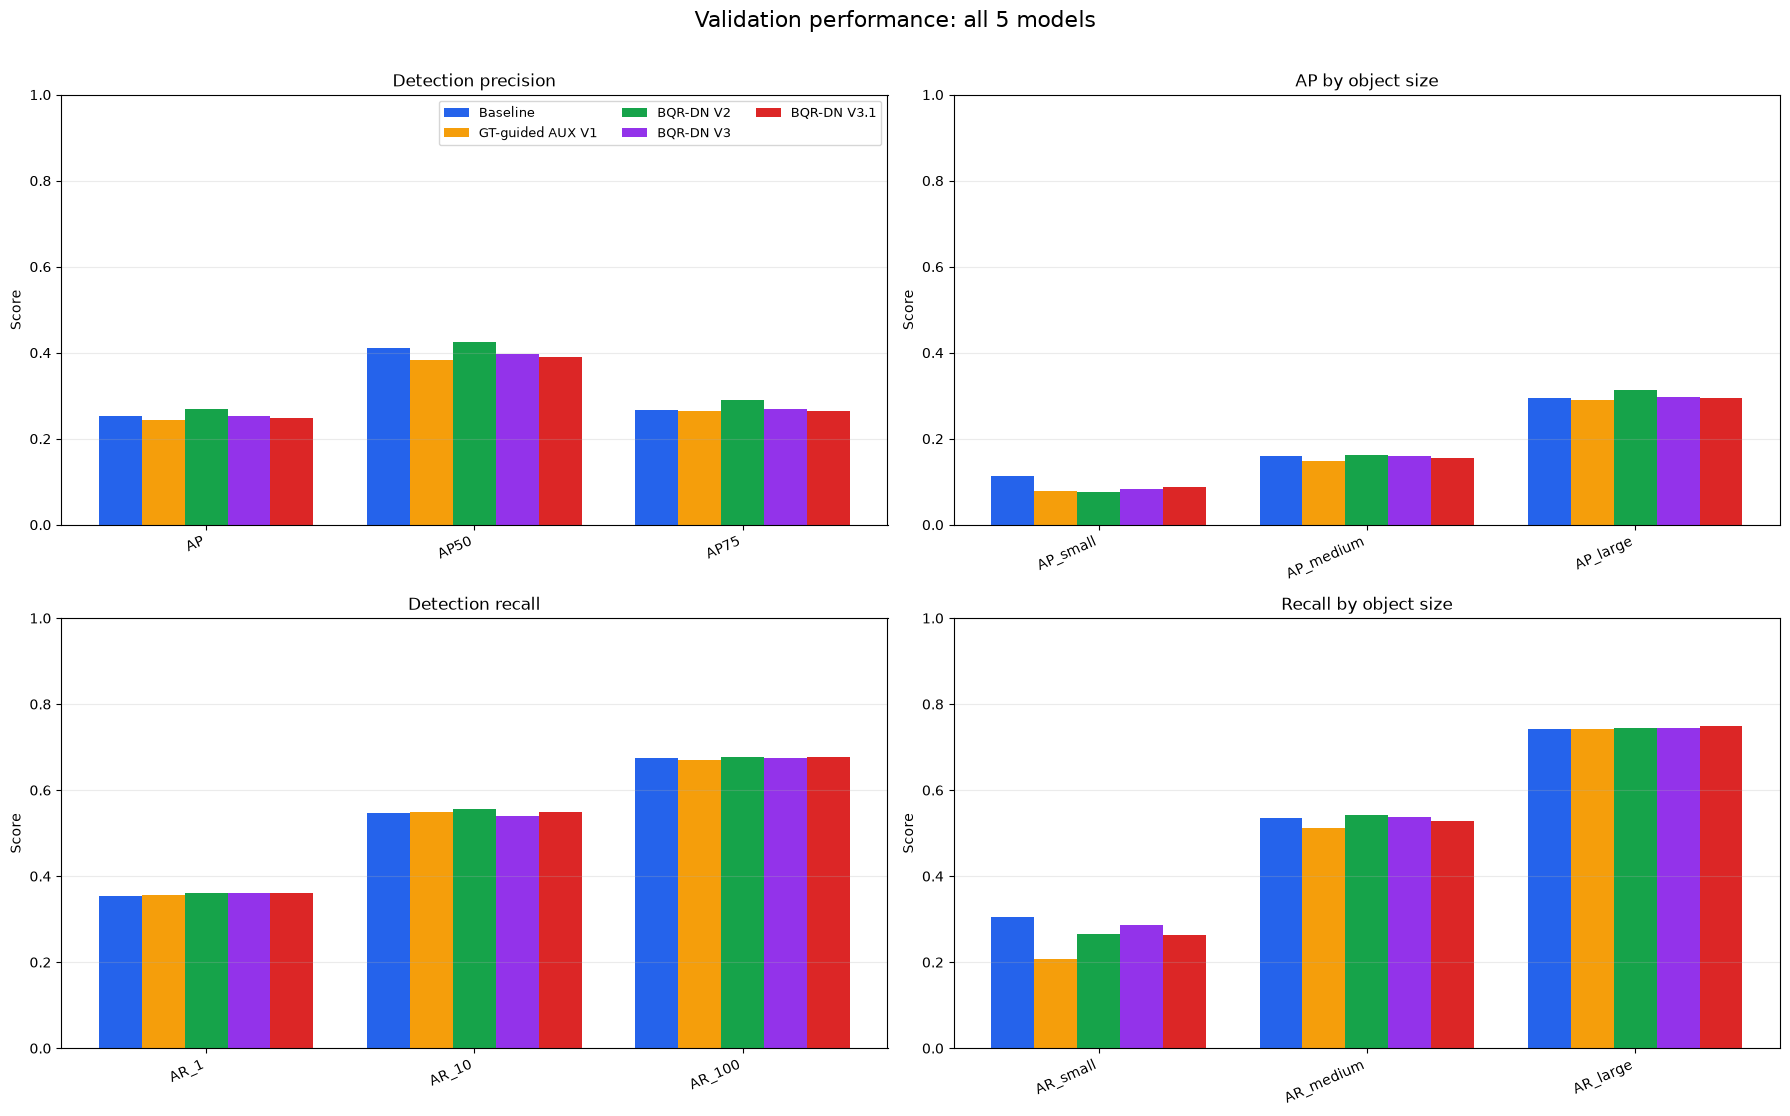

In [5]:
def grouped_bars(axis, metrics, title, source):
    positions = np.arange(len(metrics))
    width = 0.8 / len(names)
    center = (len(names) - 1) / 2
    for index, name in enumerate(names):
        axis.bar(positions + (index - center) * width, [source[name][key] for key in metrics], width, label=name, color=MODEL_SPECS[name]['color'])
    axis.set_xticks(positions, metrics, rotation=24, ha='right')
    axis.set_title(title)
    axis.set_ylim(0, 1)
    axis.grid(axis='y', alpha=0.25)

figure, axes = plt.subplots(2, 2, figsize=(18, 11))
grouped_bars(axes[0, 0], ('AP', 'AP50', 'AP75'), 'Detection precision', COCO)
grouped_bars(axes[0, 1], ('AP_small', 'AP_medium', 'AP_large'), 'AP by object size', COCO)
grouped_bars(axes[1, 0], ('AR_1', 'AR_10', 'AR_100'), 'Detection recall', COCO)
grouped_bars(axes[1, 1], ('AR_small', 'AR_medium', 'AR_large'), 'Recall by object size', COCO)
for axis in axes.flat:
    axis.set_ylabel('Score')
axes[0, 0].legend(ncol=3, fontsize=9)
figure.suptitle(f'Validation performance: all {len(names)} models', fontsize=16, y=1.01)
figure.tight_layout()

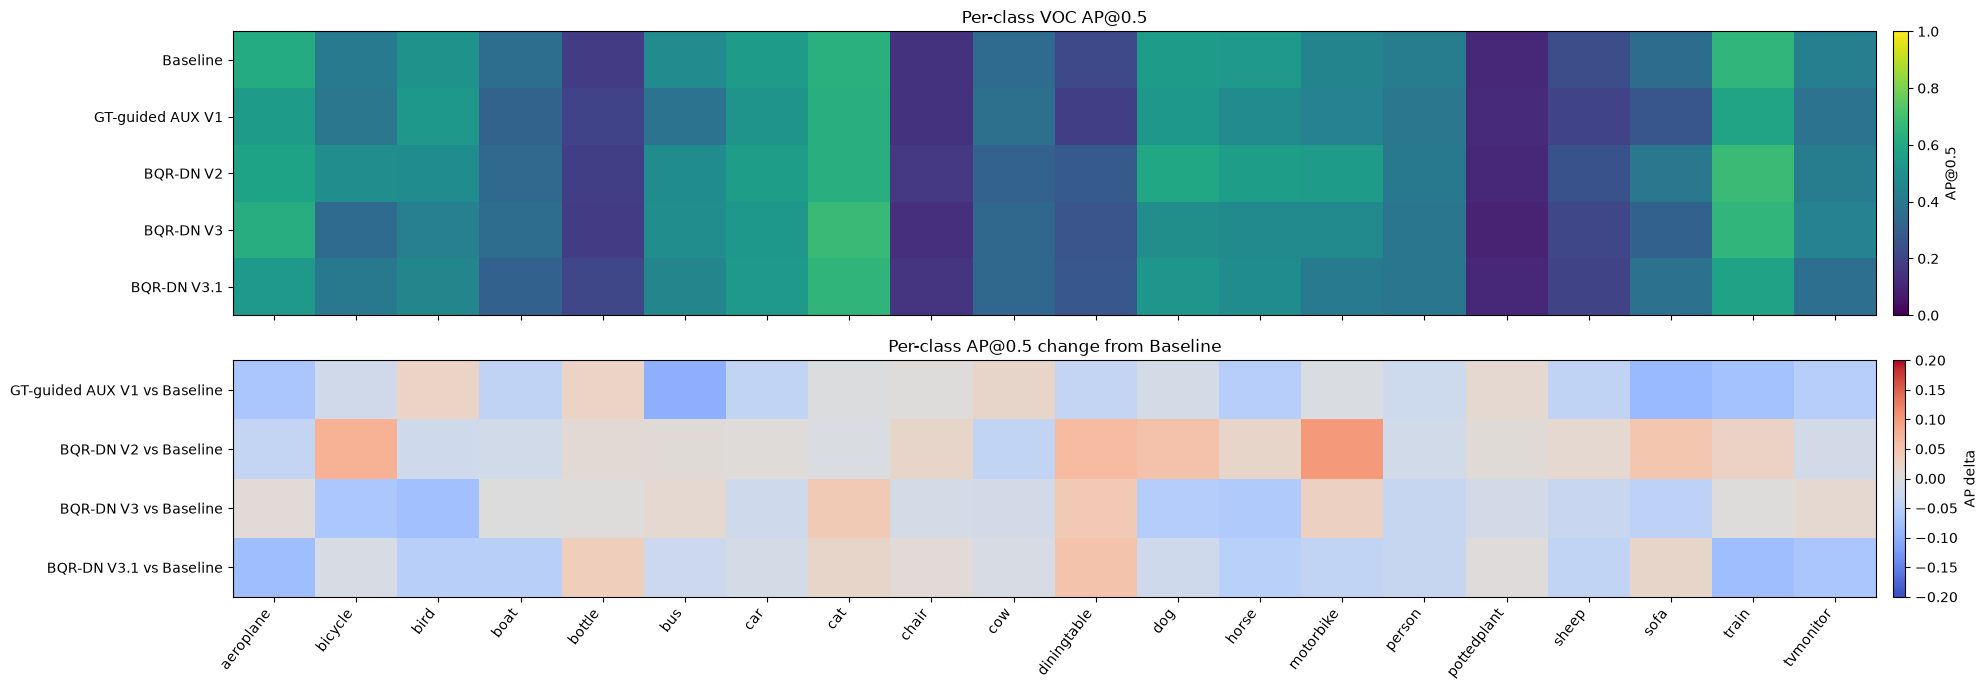

In [6]:
classes = list(COCO['Baseline']['AP50_by_class'])
matrix = np.array([[COCO[name]['AP50_by_class'][class_name] for class_name in classes] for name in names])
delta_matrix = matrix[1:] - matrix[0]

figure, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True, height_ratios=(1.2, 1))
image = axes[0].imshow(matrix, aspect='auto', vmin=0, vmax=1, cmap='viridis')
axes[0].set_yticks(range(len(names)), names)
axes[0].set_title('Per-class VOC AP@0.5')
figure.colorbar(image, ax=axes[0], fraction=0.02, pad=0.01, label='AP@0.5')

delta_image = axes[1].imshow(delta_matrix, aspect='auto', vmin=-0.20, vmax=0.20, cmap='coolwarm')
axes[1].set_yticks(range(len(names) - 1), [f'{name} vs Baseline' for name in names[1:]])
axes[1].set_title('Per-class AP@0.5 change from Baseline')
axes[1].set_xticks(range(len(classes)), classes, rotation=52, ha='right')
figure.colorbar(delta_image, ax=axes[1], fraction=0.02, pad=0.01, label='AP delta')
figure.tight_layout()

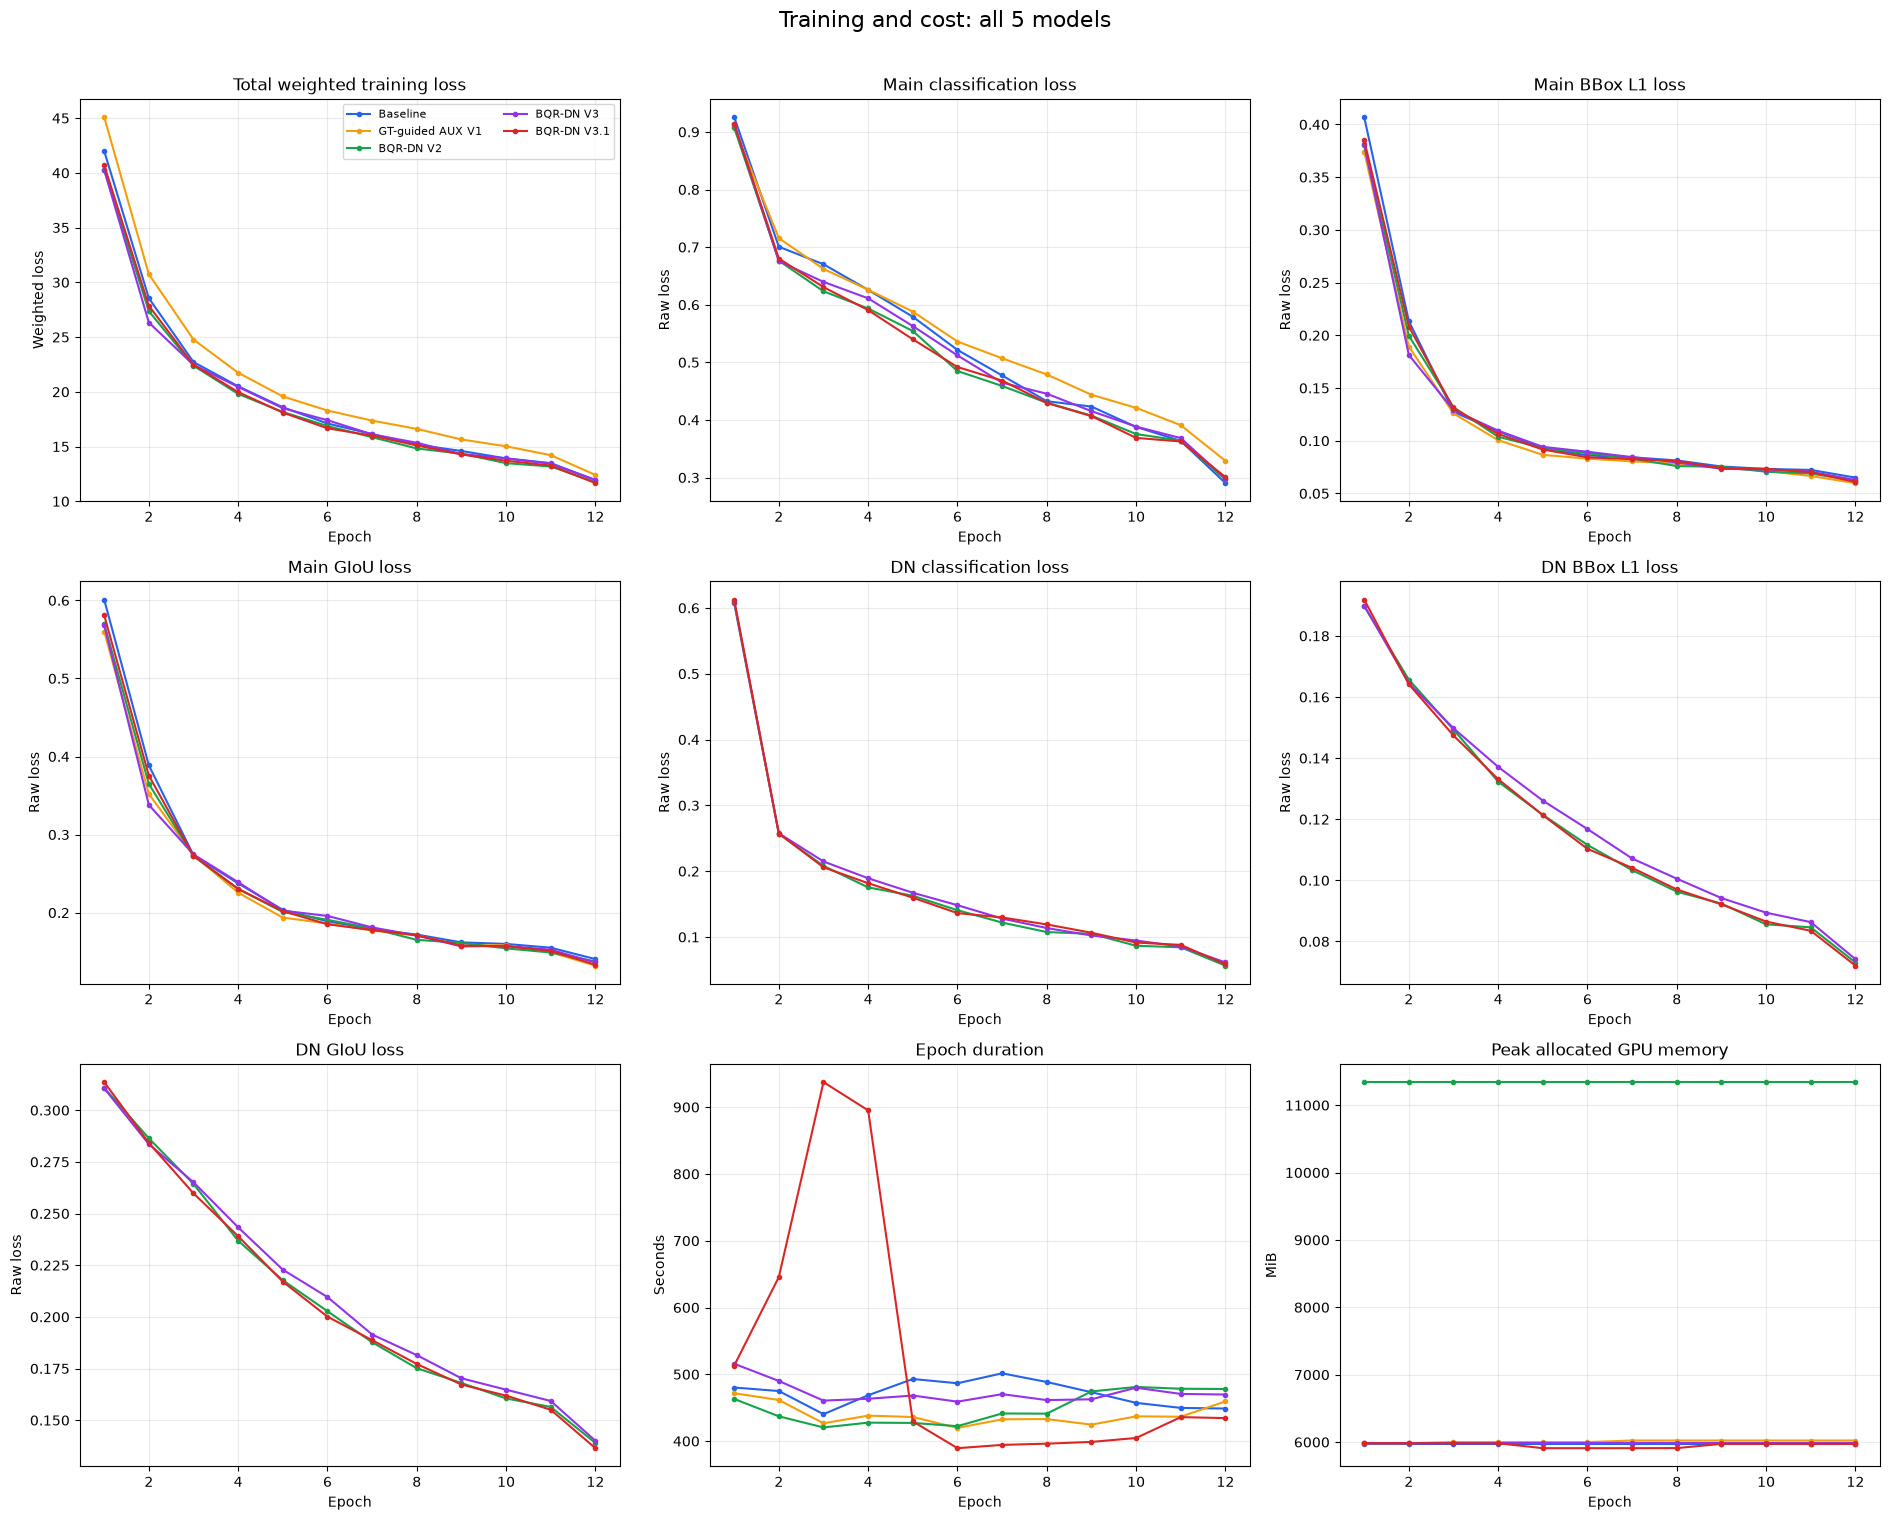

In [7]:
def plot_history(axis, key, title, ylabel='Loss'):
    for name in names:
        history = HISTORIES[name]
        values = np.asarray([row.get(key, np.nan) for row in history], dtype=float)
        if np.isfinite(values).any():
            axis.plot([row['epoch'] for row in history], values, marker='o', ms=3, label=name, color=MODEL_SPECS[name]['color'])
    axis.set(title=title, xlabel='Epoch', ylabel=ylabel)
    axis.grid(alpha=0.25)

figure, axes = plt.subplots(3, 3, figsize=(19, 15))
for axis, key, title, ylabel in (
    (axes[0, 0], 'loss', 'Total weighted training loss', 'Weighted loss'),
    (axes[0, 1], 'loss_ce', 'Main classification loss', 'Raw loss'),
    (axes[0, 2], 'loss_bbox', 'Main BBox L1 loss', 'Raw loss'),
    (axes[1, 0], 'loss_giou', 'Main GIoU loss', 'Raw loss'),
    (axes[1, 1], 'loss_ce_dn', 'DN classification loss', 'Raw loss'),
    (axes[1, 2], 'loss_bbox_dn', 'DN BBox L1 loss', 'Raw loss'),
    (axes[2, 0], 'loss_giou_dn', 'DN GIoU loss', 'Raw loss'),
    (axes[2, 1], 'seconds', 'Epoch duration', 'Seconds'),
    (axes[2, 2], 'peak_cuda_mb', 'Peak allocated GPU memory', 'MiB'),
):
    plot_history(axis, key, title, ylabel)
axes[0, 0].legend(ncol=2, fontsize=8)
figure.suptitle(f'Training and cost: all {len(names)} models', fontsize=16, y=1.01)
figure.tight_layout()

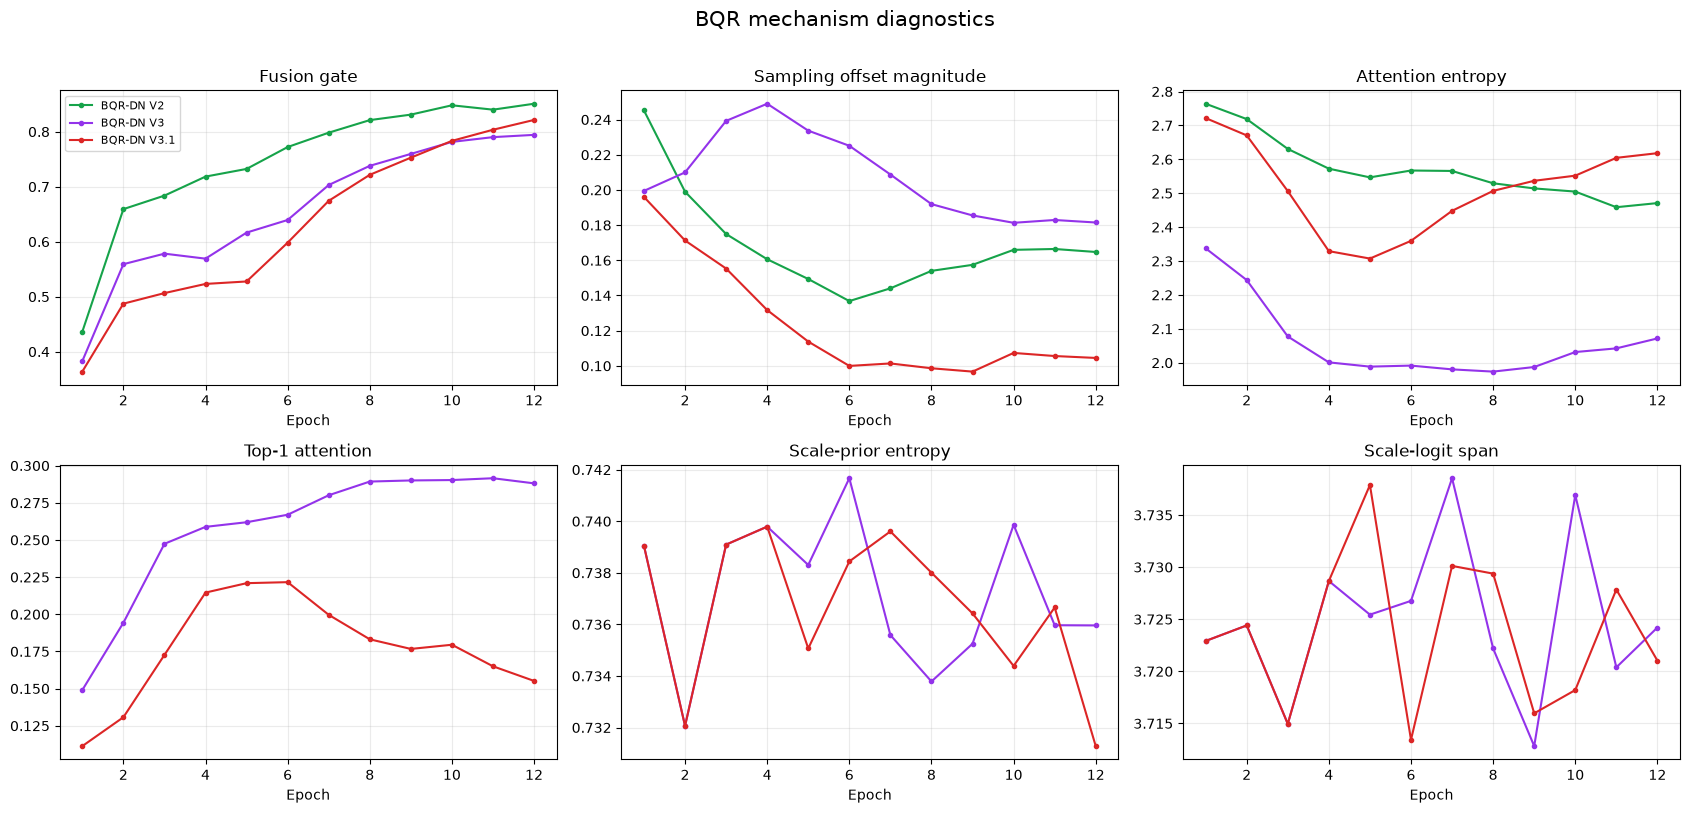

In [8]:
diagnostic_names = ('BQR-DN V2', 'BQR-DN V3', 'BQR-DN V3.1')
figure, axes = plt.subplots(2, 3, figsize=(17, 8))
for axis, key, title in (
    (axes[0, 0], 'bqr_gate_mean', 'Fusion gate'),
    (axes[0, 1], 'bqr_offset_abs_mean', 'Sampling offset magnitude'),
    (axes[0, 2], 'bqr_attention_entropy', 'Attention entropy'),
    (axes[1, 0], 'bqr_top1_attention', 'Top-1 attention'),
    (axes[1, 1], 'bqr_scale_prior_entropy', 'Scale-prior entropy'),
    (axes[1, 2], 'bqr_scale_logit_span', 'Scale-logit span'),
):
    for name in diagnostic_names:
        history = HISTORIES[name]
        values = np.asarray([row.get(key, np.nan) for row in history], dtype=float)
        if np.isfinite(values).any():
            axis.plot([row['epoch'] for row in history], values, marker='o', ms=3, label=name, color=MODEL_SPECS[name]['color'])
    axis.set(title=title, xlabel='Epoch')
    axis.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
figure.suptitle('BQR mechanism diagnostics', fontsize=15, y=1.01)
figure.tight_layout()

In [9]:
convergence = {}
for name, spec in MODEL_SPECS.items():
    run_dir = spec['checkpoint'].parent.parent
    cache = run_dir / f'convergence_val{CONVERGENCE_VAL_IMAGES}.json'
    if RUN_CONVERGENCE_EVALUATION:
        convergence[name] = evaluate_checkpoint_series(run_dir, data_root=PROJECT_ROOT / 'VOC2007', val_limit=CONVERGENCE_VAL_IMAGES, precision=EVALUATION_PRECISION)
    elif cache.is_file():
        convergence[name] = json.loads(cache.read_text(encoding='utf-8'))['epochs']

if len(convergence) != len(MODEL_SPECS):
    print('Set RUN_CONVERGENCE_EVALUATION = True once to create the same fixed-subset AP curve for all configured models.')
else:
    figure, axes = plt.subplots(1, 2, figsize=(16, 5))
    for name, rows in convergence.items():
        color = MODEL_SPECS[name]['color']
        epochs = [row['epoch'] for row in rows]
        ap = [row['voc07_map50'] for row in rows]
        axes[0].plot(epochs, ap, marker='o', label=name, color=color)
        elapsed_minutes = np.cumsum([row['seconds'] for row in HISTORIES[name]]) / 60
        axes[1].plot([elapsed_minutes[int(epoch) - 1] for epoch in epochs], ap, marker='o', label=name, color=color)
    axes[0].set(title=f'Convergence on fixed {CONVERGENCE_VAL_IMAGES}-image validation subset', xlabel='Epoch', ylabel='VOC07 mAP@0.5')
    axes[1].set(title='Accuracy versus training time', xlabel='Cumulative training minutes', ylabel='VOC07 mAP@0.5')
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
    figure.tight_layout()

Set RUN_CONVERGENCE_EVALUATION = True once to create the same fixed-subset AP curve for all configured models.
